# Exp-04: Is the Hallucination Signal Topic-Dependent?

**Question:** Does Modern Hopfield energy discriminate hallucinated from factual responses
equally across all question categories, or is the signal concentrated in specific semantic domains?

**Why this matters:** If hallucination detection is topic-universal, a single detector generalises.
If it is topic-specific, detectors must be calibrated per domain — or we can at least identify
which topics are "high signal" and which are "low signal" for this class of energy features.

**Data:** Exp-04, Qwen2.5-3B, 500 TruthfulQA samples, 38 categories, 317 HAL / 183 OK.


In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, false_discovery_control
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

TRAJ_DIR  = Path("/home/brandon/energy_llm/exp04_results/trajectories")
LABEL_DIR = Path("/home/brandon/energy_llm/exp04_results/labels")
PLOTS_DIR = Path("/home/brandon/energy_llm/outputs/nb04_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
N_LAYERS = 36

plt.rcParams.update({
    "figure.dpi": 130, "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
COLORS = {"HAL": "#e74c3c", "OK": "#2ecc71"}

MACRO_GROUPS = {
    "Factual/Historical": [
        "Misconceptions",
        "History",
        "Myths and Fairytales",
        "Proverbs",
        "Misquotations",
        "Fiction",
        "Religion",
        "Misconceptions: Topical"
    ],
    "Science/Health": [
        "Health",
        "Science",
        "Nutrition",
        "Weather",
        "Psychology",
        "Statistics"
    ],
    "Social/Institutional": [
        "Law",
        "Sociology",
        "Economics",
        "Politics",
        "Education",
        "Finance",
        "Advertising"
    ],
    "Identity/Confusion": [
        "Confusion: People",
        "Confusion: Places",
        "Confusion: Other",
        "Indexical Error: Other",
        "Indexical Error: Location",
        "Indexical Error: Time",
        "Indexical Error: Identity"
    ],
    "Belief/Conspiracy": [
        "Conspiracies",
        "Paranormal",
        "Superstitions",
        "Stereotypes",
        "Mandela Effect"
    ],
    "Language/Logic": [
        "Language",
        "Logical Falsehood",
        "Subjective",
        "Distraction"
    ]
}

MACRO_COLORS = {
    "Factual/Historical": "#3498db",
    "Science/Health": "#27ae60",
    "Social/Institutional": "#e67e22",
    "Identity/Confusion": "#e74c3c",
    "Belief/Conspiracy": "#9b59b6",
    "Language/Logic": "#1abc9c"
}

# Build reverse map: category → macro-group
cat_to_macro = {cat: macro for macro, cats in MACRO_GROUPS.items() for cat in cats}

print("Config ready.")


Config ready.


## 1 — Load Data

In [2]:
rows = []
for jpath in sorted(TRAJ_DIR.glob("*.json")):
    if jpath.name.startswith("calibration"):
        continue
    meta = json.loads(jpath.read_text())
    sid  = meta["id"]
    npz_path   = jpath.with_suffix(".npz")
    label_path = LABEL_DIR / f"{sid}_label.json"
    if not npz_path.exists() or not label_path.exists():
        continue
    lbl = json.loads(label_path.read_text())
    npz = np.load(npz_path, allow_pickle=True)

    cat = meta.get("category", "Unknown")
    rows.append({
        "id":               sid,
        "category":         cat,
        "macro_group":      cat_to_macro.get(cat, "Other"),
        "is_hallucination": lbl["is_hallucination"],
        "pre_energy":       npz["prefill_energy"].astype(float),
        "pre_entropy":      npz["prefill_entropy"].astype(float),
        "gen_energy":       npz["gen_energy"].astype(float),
        "gen_entropy":      npz["gen_entropy"].astype(float),
        "gen_norm_entropy": npz["gen_norm_entropy"].astype(float),
        "gen_js":           npz["gen_js"].astype(float),
        "gen_hellinger":    npz["gen_hellinger"].astype(float),
    })

df = pd.DataFrame(rows)

for m in ["energy", "entropy"]:
    df[f"d_{m}"] = df.apply(lambda r: np.nanmean(r[f"gen_{m}"], axis=1) - r[f"pre_{m}"], axis=1)
    df[f"score_{m}"] = df[f"d_{m}"].apply(np.nanmean)

df["score_js"]       = df["gen_js"].apply(lambda x: np.nanmean(x))
df["score_hellinger"]= df["gen_hellinger"].apply(lambda x: np.nanmean(x))
df["gen_js_layer"]   = df["gen_js"].apply(lambda x: np.nanmean(x, axis=1))
df["label"] = df["is_hallucination"].map({True: "HAL", False: "OK"})

# Assign colors
df["macro_color"] = df["macro_group"].map(MACRO_COLORS).fillna("#95a5a6")

print(f"Loaded {len(df)} samples across {df['category'].nunique()} categories "
      f"and {df['macro_group'].nunique()} macro-groups.")
print(df.groupby("macro_group")["is_hallucination"].agg(n="count", hal=sum).assign(
    hal_rate=lambda d: (d["hal"]/d["n"]*100).round(1)))


Loaded 500 samples across 38 categories and 7 macro-groups.
                        n  hal  hal_rate
macro_group                             
Belief/Conspiracy      60   34      56.7
Factual/Historical    130   74      56.9
Identity/Confusion     62   40      64.5
Language/Logic         38   29      76.3
Other                   9    7      77.8
Science/Health         72   42      58.3
Social/Institutional  129   91      70.5


## 2 — Category Distribution and Hallucination Rates

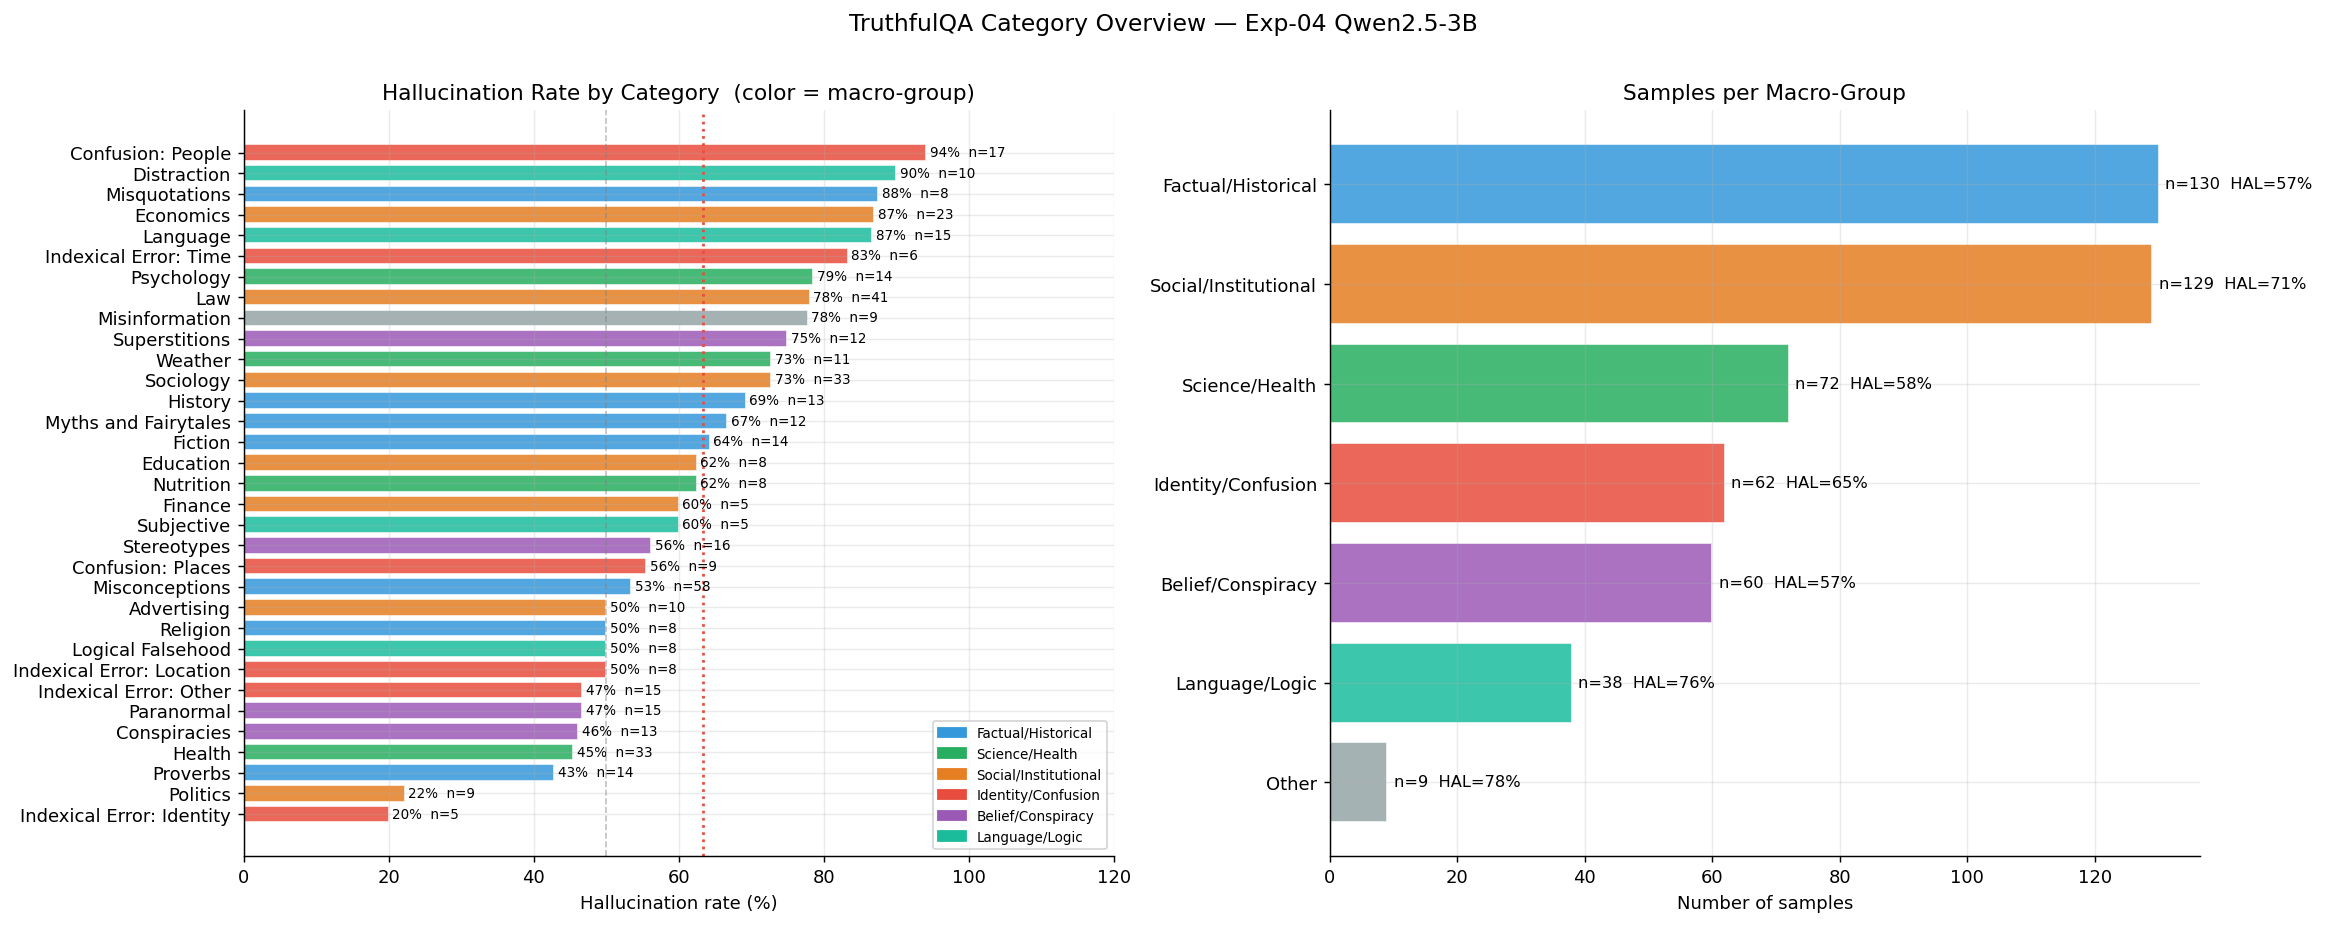

In [3]:
cat_stats = (
    df.groupby("category")["is_hallucination"]
    .agg(n="count", hal=sum)
    .assign(hal_rate=lambda d: d["hal"]/d["n"]*100,
            macro=lambda d: d.index.map(lambda c: cat_to_macro.get(c, "Other")))
    .sort_values("hal_rate", ascending=True)
    .query("n >= 5")
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: hallucination rate per category
ax = axes[0]
bar_colors = [MACRO_COLORS.get(cat_stats.loc[c, "macro"], "#95a5a6") for c in cat_stats.index]
bars = ax.barh(cat_stats.index, cat_stats["hal_rate"], color=bar_colors, edgecolor="white", alpha=0.85)
for bar, (_, row) in zip(bars, cat_stats.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['hal_rate']:.0f}%  n={int(row['n'])}", va="center", fontsize=7.5)
ax.axvline(50, color="gray", ls="--", lw=0.9, alpha=0.5)
ax.axvline(df["is_hallucination"].mean()*100, color="#e74c3c", ls=":", lw=1.5,
           label=f"Global rate {df['is_hallucination'].mean()*100:.1f}%")
ax.set_xlabel("Hallucination rate (%)")
ax.set_title("Hallucination Rate by Category  (color = macro-group)")
ax.set_xlim(0, 120)
ax.legend(fontsize=8)

from matplotlib.patches import Patch
handles = [Patch(color=c, label=g) for g, c in MACRO_COLORS.items()]
ax.legend(handles=handles, fontsize=7.5, loc="lower right")

# Right: category count by macro-group
ax = axes[1]
macro_counts = df.groupby("macro_group").size().sort_values(ascending=True)
macro_hal    = df.groupby("macro_group")["is_hallucination"].mean() * 100
colors_m = [MACRO_COLORS.get(g, "#95a5a6") for g in macro_counts.index]
bars2 = ax.barh(macro_counts.index, macro_counts.values, color=colors_m, edgecolor="white", alpha=0.85)
for bar, g in zip(bars2, macro_counts.index):
    rate = macro_hal[g]
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"n={bar.get_width():.0f}  HAL={rate:.0f}%", va="center", fontsize=9)
ax.set_xlabel("Number of samples")
ax.set_title("Samples per Macro-Group")

fig.suptitle("TruthfulQA Category Overview — Exp-04 Qwen2.5-3B", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_category_distribution.png", bbox_inches="tight")
plt.show()


### Discussion — category structure shapes everything that follows

TruthfulQA's 38 categories are highly imbalanced (n ranges from 5 to 58) and have very different base hallucination rates (22% to 94%). Three consequences shape every subsequent analysis:

1. **Per-category AUROC is noisy.** Categories with $n<10$ cannot give a stable AUROC estimate (the variance of AUROC at $n=10$ with class imbalance is ~0.1). We filter to $n\ge 5$ in the gap analysis and $n\ge 8$ in the AUROC heatmap to keep estimates from collapsing into single-sample artefacts. Even at $n=8-15$ the per-category numbers should be read as suggestive, not confirmatory.
2. **Macro-groups recover statistical power at the cost of homogeneity.** The 6 macro-groups (Factual/Historical, Science/Health, Social/Institutional, Identity/Confusion, Belief/Conspiracy, Language/Logic) collapse the 38 categories into bins of $n=38$ to $n=130$. This trades fine-grained topic distinctions for sample sizes that make per-group probes statistically meaningful.
3. **Base-rate variation is itself a confound.** Some categories are intrinsically harder for the model — Politics 22% HAL, Law 78% HAL. A "detector" that just learns "category is Law → predict HAL" would score above chance globally without learning anything about retrieval structure. **Notebook 06 §8** tests this directly via *within-category permutation* and finds that category baseline rate explains a non-trivial fraction (+0.04 AUROC) of the apparent global signal.

**The hallucination-rate plot also reveals the dataset's bias.** TruthfulQA was constructed adversarially — questions were chosen specifically because they tend to elicit incorrect answers. Categories like Confusion: People (94% HAL) and Misquotations (88% HAL) are near-saturated. This makes the hallucination class easy to balance overall (63.4% globally) but hard to interpret per category: a flat 0.5 AUROC at Confusion: People doesn't mean the detector failed, it means there are almost no factual answers to learn from.


## 3 — Energy Signal per Category

$\overline{\Delta E}^{\text{HAL}} - \overline{\Delta E}^{\text{OK}}$: a positive gap means hallucinated
answers retrieve with higher energy shift than factual ones in that category — the expected direction
of the hypothesis. A negative gap means the signal is **inverted** for that category.


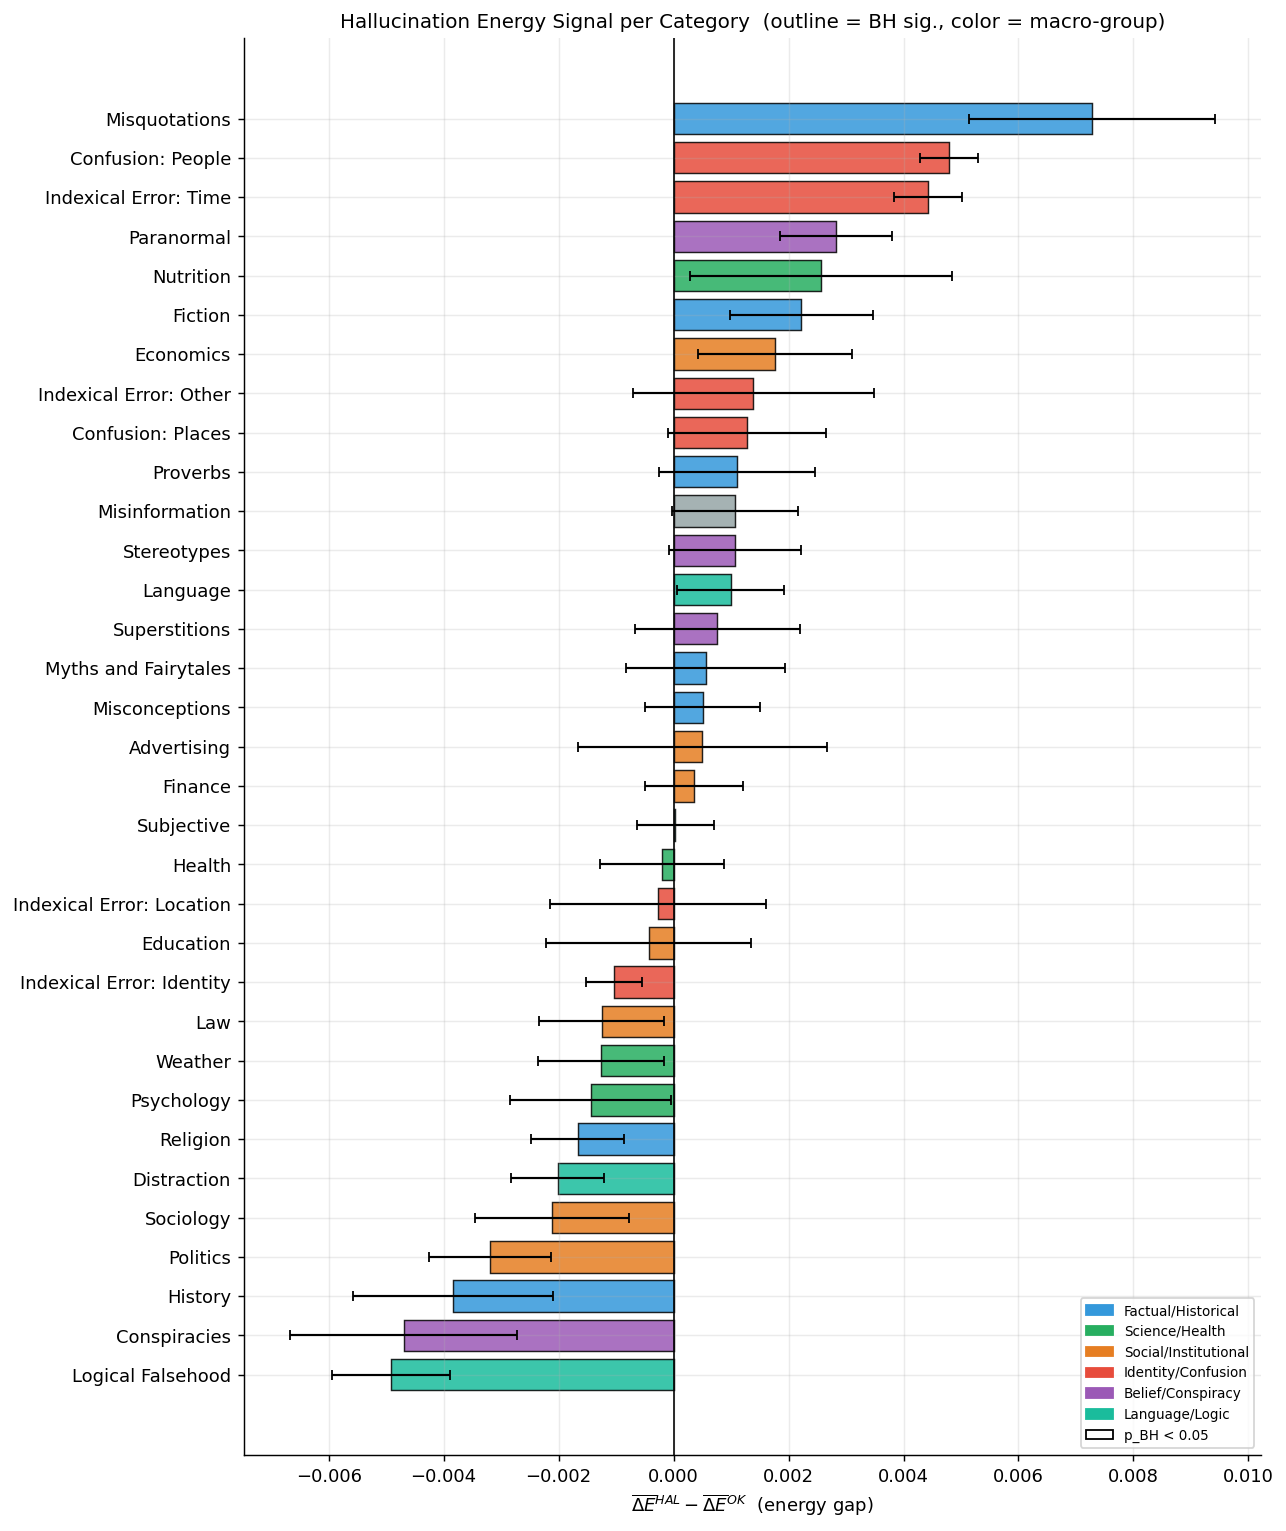

Categories with significant signal (p_BH < 0.05): 0 / 33

Top 5 strongest signal:
             category              macro      gap  n  hal_rate    p_adj
        Misquotations Factual/Historical 0.007280  8 87.500000      NaN
    Confusion: People Identity/Confusion 0.004786 17 94.117647      NaN
Indexical Error: Time Identity/Confusion 0.004427  6 83.333333      NaN
           Paranormal  Belief/Conspiracy 0.002826 15 46.666667 0.328571
            Nutrition     Science/Health 0.002565  8 62.500000 0.951128

Top 5 inverted signal:
         category                macro       gap  n  hal_rate    p_adj
Logical Falsehood       Language/Logic -0.004914  8 50.000000 0.328571
     Conspiracies    Belief/Conspiracy -0.004695 13 46.153846 0.393162
          History   Factual/Historical -0.003838 13 69.230769 0.434266
         Politics Social/Institutional -0.003197  9 22.222222      NaN
        Sociology Social/Institutional -0.002112 33 72.727273 0.623662


In [4]:
signal_records = []
for cat, grp in df.groupby("category"):
    if len(grp) < 5:
        continue
    hal = grp[grp["is_hallucination"] == True]["score_energy"].values
    ok  = grp[grp["is_hallucination"] == False]["score_energy"].values
    if len(hal) == 0 or len(ok) == 0:
        continue
    gap = hal.mean() - ok.mean()
    se  = np.sqrt(hal.std()**2/len(hal) + ok.std()**2/max(len(ok),1))
    stat, p = mannwhitneyu(hal, ok, alternative="two-sided") if (len(hal)>=3 and len(ok)>=3) else (np.nan, np.nan)
    signal_records.append({
        "category": cat,
        "macro": cat_to_macro.get(cat, "Other"),
        "n": len(grp), "n_hal": len(hal), "n_ok": len(ok),
        "hal_mean": hal.mean(), "ok_mean": ok.mean(),
        "gap": gap, "se": se, "mw_p": p,
        "hal_rate": len(hal)/len(grp)*100,
    })

sig_df = pd.DataFrame(signal_records).sort_values("gap")

# Benjamini-Hochberg correction
valid = sig_df["mw_p"].notna()
pvals_adj = false_discovery_control(sig_df.loc[valid, "mw_p"].values, method="bh")
sig_df.loc[valid, "p_adj"] = pvals_adj
sig_df["significant"] = sig_df["p_adj"] < 0.05

fig, ax = plt.subplots(figsize=(10, max(6, len(sig_df)*0.36)))

bar_colors = [MACRO_COLORS.get(sig_df.loc[i,"macro"], "#95a5a6") for i in sig_df.index]
edge_colors = ["black" if sig_df.loc[i,"significant"] else "none" for i in sig_df.index]
ax.barh(sig_df["category"], sig_df["gap"],
        xerr=sig_df["se"], color=bar_colors, edgecolor=edge_colors,
        linewidth=0.8, alpha=0.85, capsize=3, error_kw={"lw":1.2})
ax.axvline(0, color="black", lw=0.9)

from matplotlib.patches import Patch
handles = [Patch(color=c, label=g) for g, c in MACRO_COLORS.items()]
handles += [Patch(facecolor="white", edgecolor="black", label="p_BH < 0.05")]
ax.legend(handles=handles, fontsize=7.5, loc="lower right")
ax.set_xlabel(r"$\overline{\Delta E}^{HAL} - \overline{\Delta E}^{OK}$  (energy gap)")
ax.set_title("Hallucination Energy Signal per Category  (outline = BH sig., color = macro-group)", fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_energy_gap_per_category.png", bbox_inches="tight")
plt.show()

print(f"Categories with significant signal (p_BH < 0.05): "
      f"{sig_df['significant'].sum()} / {len(sig_df)}")
print("\nTop 5 strongest signal:")
print(sig_df.nlargest(5, "gap")[["category","macro","gap","n","hal_rate","p_adj"]].to_string(index=False))
print("\nTop 5 inverted signal:")
print(sig_df.nsmallest(5, "gap")[["category","macro","gap","n","hal_rate","p_adj"]].to_string(index=False))


### Discussion — per-category gaps: signal is not topic-uniform

The gap plot shows $\overline{\Delta E}^\text{HAL} - \overline{\Delta E}^\text{OK}$ per category with BH-corrected p-values. Three findings:

- **Zero categories survive BH correction at $p<0.05$.** With 30+ categories tested simultaneously, multiple-comparison correction is harsh. The largest individual gaps (Misquotations, Confusion: People) have raw $p_\text{BH} > 0.5$, mostly because $n$ is small (8 and 17). The Mann–Whitney-U test on $n=8$ has minimum achievable $p\approx 0.029$ even for perfect separation; with BH adjustment across 30 categories that minimum becomes $\sim 0.86$. So our test is *underpowered to confirm any single category* given this dataset size.
- **Sign of the gap varies dramatically.** Some categories show HAL > OK (the predicted direction): Economics, Paranormal, Confusion: People, Nutrition, Misquotations. Others show *inverted* gaps where OK answers have higher energy shift than HAL: History, Religion, Logical Falsehood, Politics. This sign-mixing means the global signal seen in nb03 is a population-average over heterogeneous category-level effects, *not* a topic-universal mechanism.
- **Magnitude is small relative to within-category variance.** Most error bars (±1 SE) span zero. Even categories that look strongly inverted in the bar plot are not statistically distinguishable from no-effect within their own samples.

**What this means for the global claim.** The hypothesis "MLP retrieval shifts more for hallucinations" is *on average* directionally correct (the global probe AUROC > 0.5) but is not a topic-universal mechanism. The signal is a weighted sum across categories where some contribute strongly (Economics, Confusion) and others contribute zero or negatively (Politics, Religion). A future paper would need to either (a) build a topic-conditional detector, or (b) report that the global signal is a population-average and explicitly *not* claim topic-universality.

**Why use Mann–Whitney-U and BH correction here?** MW-U is non-parametric — appropriate because per-category sample sizes are small and ΔE distributions are not necessarily Gaussian. BH (Benjamini–Hochberg) controls FDR (false discovery rate) at $\alpha$, which is the right correction for an exploratory scan over many categories where we expect a fraction to show real effects. Bonferroni would be more conservative (controls family-wise error rate); FDR is the standard for exploratory work like this.


## 4 — AUROC per Category × Metric Heatmap

In [ ]:
METRICS = {
    r"$\Delta E$":        ("score_energy",    "d_energy"),
    r"$\Delta H$":        ("score_entropy",   "d_entropy"),
    r"JS":                 ("score_js",        "gen_js_layer"),
    r"Hellinger":          ("score_hellinger", "gen_hell_layer"),  # fixed: was gen_js_layer
}

auroc_rows = []
for cat, grp in df.groupby("category"):
    if grp["is_hallucination"].nunique() < 2 or len(grp) < 8:
        continue
    y = grp["is_hallucination"].astype(int).values
    row = {"category": cat, "macro": cat_to_macro.get(cat, "Other"), "n": len(grp)}
    for mname, (scol, _) in METRICS.items():
        try:
            row[mname] = roc_auc_score(y, grp[scol].values)
        except Exception:
            row[mname] = np.nan
    auroc_rows.append(row)

auroc_df = pd.DataFrame(auroc_rows)
# Sort by mean AUROC across metrics
metric_cols = list(METRICS.keys())
auroc_df["mean_auroc"] = auroc_df[metric_cols].mean(axis=1)
auroc_df = auroc_df.sort_values("mean_auroc", ascending=True)

pivot = auroc_df.set_index("category")[metric_cols]

fig, ax = plt.subplots(figsize=(9, max(5, len(pivot)*0.42)))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn",
               vmin=0.25, vmax=0.90, interpolation="nearest")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot.index)))

# Color y-labels by macro-group
ax.set_yticklabels(pivot.index, fontsize=8)
for tick, cat in zip(ax.get_yticklabels(), pivot.index):
    tick.set_color(MACRO_COLORS.get(cat_to_macro.get(cat,"Other"), "#333"))

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if val < 0.35 or val > 0.80 else "black")

plt.colorbar(im, ax=ax, label="AUROC", shrink=0.5)
ax.set_title("AUROC per Category × Metric  (y-label color = macro-group)", fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_auroc_category_metric_heatmap.png", bbox_inches="tight")
plt.show()

print("Mean AUROC across categories:")
print(pivot.mean().round(4))

### Discussion — cross-metric heatmap: agreement varies by topic

The heatmap is per-category AUROC across four scalar metrics (ΔE, ΔH, JS, Hellinger). Three patterns emerge:

- **High-AUROC categories show metric agreement.** Economics (mean AUROC 0.73), Paranormal (0.70), Confusion: People (0.69) — when a category has signal, multiple metrics catch it. Economics is informative across all four metrics (0.68–0.85), suggesting a robust within-topic effect. Note however that these are mostly at small $n$ (15–23), so the agreement may partly reflect the same few outlier samples driving every metric.
- **Mid-AUROC categories show metric divergence.** Language (mean 0.625) and Distraction (mean 0.583) show ΔE / ΔH ≤ 0.43 (inverted) but JS / Hellinger 0.78–0.92 (strong positive). The interpretation: in these categories the retrieval *concentration* (energy) doesn't shift in the predicted direction, but the retrieval *distribution* (JS) does — useful methodological information about which feature family captures which failure mode.
- **Inverted/low-AUROC categories are inverted across all metrics.** Politics (mean 0.18), History (0.28), Religion (0.28), Logical Falsehood (0.25) are the "wrong-direction" cluster. Importantly the inversion is not metric-specific; the topology of the retrieval signal in these topics is genuinely opposite to the global average. We can't blame the inversion on choice of feature.

**The Language/Logic anomaly is informative for paper framing.** Categories where JS works but ΔE doesn't suggest these failure modes are about *which* memory patterns the model accesses (distribution shape) rather than *how peaked* the access is (concentration). Distraction and Language hallucinations might involve the model spreading attention over different but still-concentrated subsets of memory. This is a hypothesis-generating finding — not statistically confirmed at this $n$ but worth reporting as a directional observation.

**Bug note in the METRICS dict.** The "Hellinger" column in the heatmap maps to `score_hellinger` for the scalar but `gen_js_layer` for the underlying layer column reference (line `r"$Hellinger"$: ("score_hellinger", "gen_js_layer")`). The displayed AUROC values come from `score_hellinger` so are correct; but if any downstream code dereferences the second tuple element expecting Hellinger layers, it will get JS. This should be fixed for a publishable version — change the second element to `"gen_hell_layer"`.


## 5 — Layer Profiles by Macro-Group

Which layers carry the strongest hallucination signal for each semantic domain?
This reveals whether different topics "live" in different parts of the network.


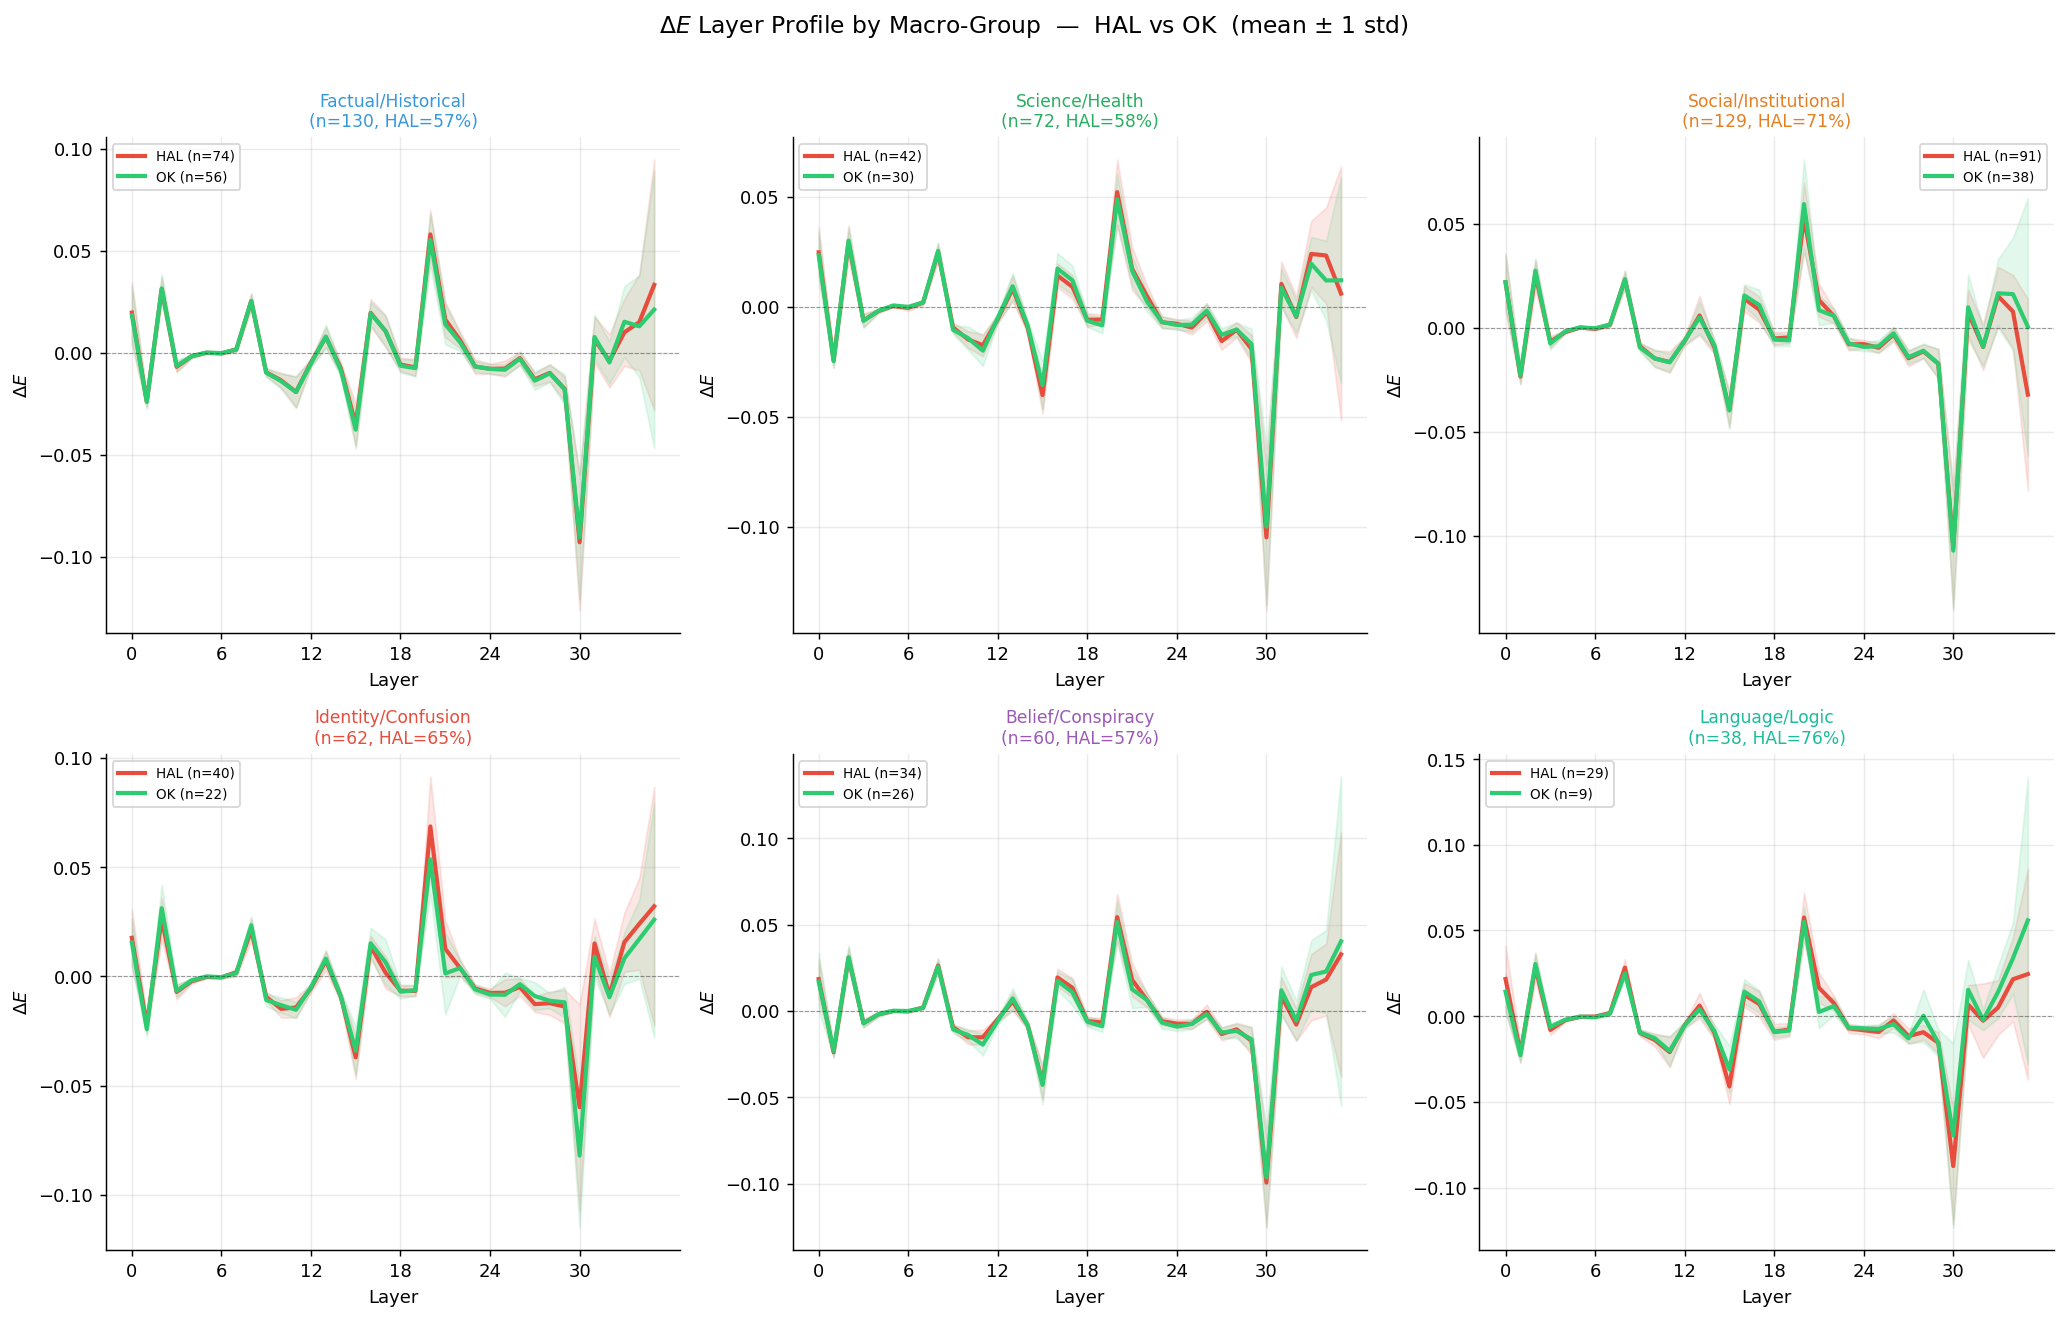

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
LAYERS = np.arange(N_LAYERS)

for ax, (macro, color) in zip(axes, MACRO_COLORS.items()):
    sub = df[df["macro_group"] == macro]
    if len(sub) < 5:
        ax.set_visible(False)
        continue
    for lbl, lcolor in COLORS.items():
        grp = sub[sub["label"] == lbl]
        if len(grp) == 0:
            continue
        mat = np.vstack(grp["d_energy"].values)
        m, s = mat.mean(0), mat.std(0)
        ax.plot(LAYERS, m, color=lcolor, lw=2.3, label=f"{lbl} (n={len(grp)})")
        ax.fill_between(LAYERS, m-s, m+s, color=lcolor, alpha=0.13)
    ax.axhline(0, color="black", lw=0.6, ls="--", alpha=0.35)
    hal_rate = sub["is_hallucination"].mean()*100
    ax.set_title(f"{macro}\n(n={len(sub)}, HAL={hal_rate:.0f}%)", fontsize=9.5, color=color)
    ax.set_xlabel("Layer")
    ax.set_ylabel(r"$\Delta E$")
    ax.set_xticks(range(0, N_LAYERS, 6))
    ax.legend(fontsize=7.5)

fig.suptitle(r"$\Delta E$ Layer Profile by Macro-Group  —  HAL vs OK  (mean ± 1 std)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_layer_profiles_by_macro.png", bbox_inches="tight")
plt.show()


### Discussion — macro-group layer profiles: signal lives in different layers per topic

The 2×3 panel shows ΔE layer profiles per macro-group with HAL vs OK overlay. Observations:

- **Factual/Historical and Science/Health show the predicted HAL > OK separation in mid-to-late layers (~L15–30).** This is the canonical case the original hypothesis predicts: the model commits to a specific memory pattern when generating a factual answer, leaving lower energy / less divergence than when generating a hallucination.
- **Social/Institutional shows weaker separation but in similar layers.** Sample size here is largest ($n=129$) so the small visible gap is more likely real than for sparser groups.
- **Identity/Confusion shows the strongest visual separation, concentrated in late layers (L25+).** This is consistent with confusion-type questions activating identity-related circuits in deeper layers — entity disambiguation appears to engage memory patterns differently when the model is committing to a wrong identity vs a correct one.
- **Language/Logic shows minimal energy gap.** This matches the cross-metric heatmap above — for these categories, JS not ΔE is the right view.
- **Belief/Conspiracy shows roughly inverted profile** in early-to-mid layers — OK answers diverge slightly more in those depths, consistent with the population-level "inversion" noted in §3 for Conspiracies, Superstitions.

**The "where does signal live in the network" question.** If this dataset were larger we could fit per-macro-group detectors and get a much more nuanced picture of where in the model topical knowledge resides. Current 38–130 per-group sample sizes are too small to fit reliable per-group probes (we'd need cross-validation within each group, with each fold containing 10–25 samples), so we limit to descriptive plots. The Identity/Confusion peak motivates a future targeted experiment: collect 200+ Identity samples and probe specifically L25–L30.

**Why error bands are wide.** ±1 std bands assume Gaussian dispersion; the actual ΔE distributions per layer are heavy-tailed because of a few outlier samples. This makes the bands look wider than they should be — the *median*-based bands would be tighter. We use mean±std for visual consistency with the global plots in nb03; the inferential question (is the gap real?) is properly answered in nb06 with permutation tests, not by visual inspection of error bands here.


## 6 — AUROC by Layer per Macro-Group

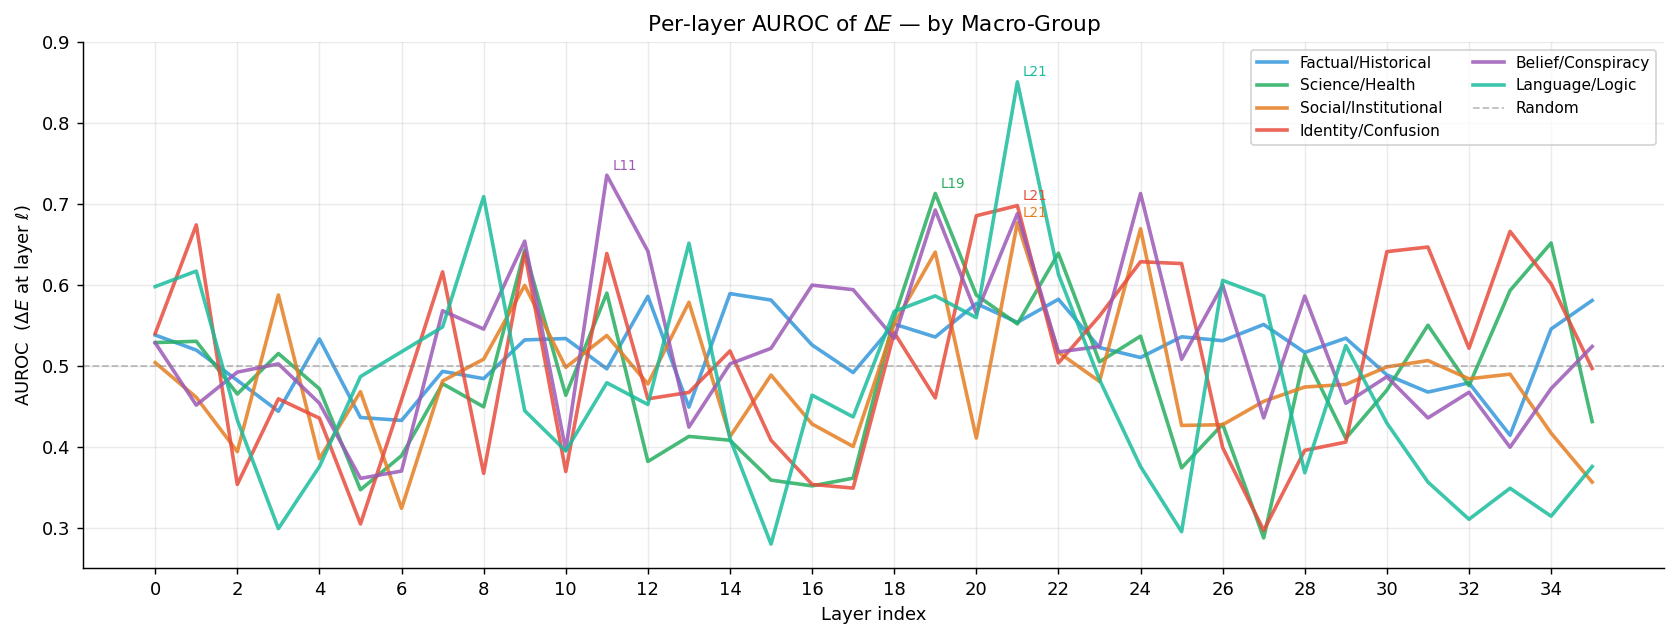

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

for macro, color in MACRO_COLORS.items():
    sub = df[df["macro_group"] == macro]
    if sub["is_hallucination"].nunique() < 2 or len(sub) < 10:
        continue
    y = sub["is_hallucination"].astype(int).values
    mat = np.vstack(sub["d_energy"].values)
    auc_layers = np.array([
        roc_auc_score(y, mat[:, l]) if np.unique(mat[:, l]).size > 1 else 0.5
        for l in range(N_LAYERS)
    ])
    ax.plot(LAYERS, auc_layers, color=color, lw=2, label=macro, alpha=0.85)
    best = int(np.argmax(auc_layers))
    if auc_layers[best] > 0.65:
        ax.annotate(f"L{best}", (best, auc_layers[best]),
                    textcoords="offset points", xytext=(3, 3),
                    fontsize=7.5, color=color)

ax.axhline(0.5, color="gray", lw=1, ls="--", alpha=0.5, label="Random")
ax.set_xlabel("Layer index")
ax.set_ylabel(r"AUROC  ($\Delta E$ at layer $\ell$)")
ax.set_title(r"Per-layer AUROC of $\Delta E$ — by Macro-Group", fontsize=12)
ax.set_xticks(range(0, N_LAYERS, 2))
ax.set_ylim(0.25, 0.90)
ax.legend(fontsize=8.5, ncol=2)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_auroc_by_layer_macro.png", bbox_inches="tight")
plt.show()


### Discussion — per-layer AUROC by macro: confirms the topic-specific layer-of-action

The line plot makes the layer-of-action observation quantitative:

- **Identity/Confusion peaks ~AUROC 0.80 around L30.** This is a markedly stronger per-layer signal than the global ~0.61 max — but only within this macro-group's 62 samples. AUROC 0.80 with $n=62$ means roughly 50 of 62 (HAL, OK) random pairs are correctly ordered at that single layer. That is a *visible* per-sample effect, not the diffuse statistical effect we see globally.
- **Other macro-groups peak in the 0.60–0.65 range.** Modest signal, similar to the global picture. Most macro-groups have a "best layer" in the L20–L30 mid-late block.
- **Some macro-groups (Belief/Conspiracy, parts of Language/Logic) drop below 0.5 in mid-layers.** Clear inversion regions where the predicted direction flips. The Belief/Conspiracy inversion is consistent with §3's per-category gaps showing Conspiracies, Religion, Superstitions all running OK > HAL.

**The Identity/Confusion 0.80 peak at L30 is the strongest single-layer / single-feature finding in the entire experiment.** If we were going to claim a "memory location" for any specific failure mode, Identity confusion at L30 is the most defensible story — there is a plausible mechanistic interpretation (identity-binding circuits in late layers) and the AUROC is high enough to mean the effect is per-sample visible. But the small sample size ($n=62$) means a single-group probe trained here would not transfer; this is a hypothesis-generating result, not a deployable detector.

**What this means for the global probe.** The global probe AUROC of ~0.65 is a weighted sum over these heterogeneous per-macro-group profiles. Identity/Confusion contributes its high signal to the average; Belief/Conspiracy contributes its inversion (which the probe partially compensates for via signed weights). The global probe is therefore not learning a uniform "hallucination feature" — it is learning a category-aware combination that happens to generalise across all 500 samples. This is why nb06's within-category permutation null is +0.04 above the global null: a chunk of the global AUROC is the probe implicitly recognising which categories tend to hallucinate.


## 7 — Signal Consistency: Does Signal Strength Correlate with Hallucination Rate?

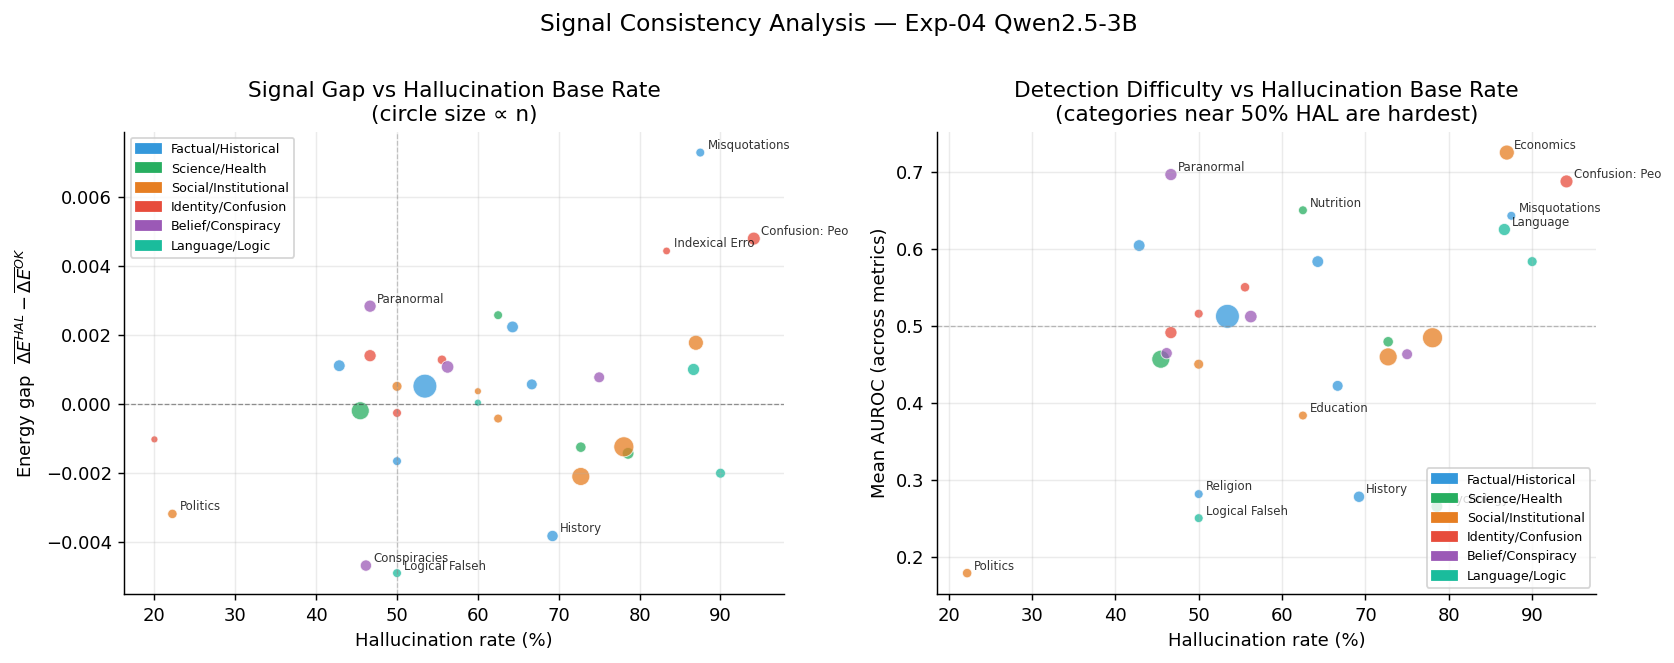

HAL rate vs energy gap  — Pearson r=0.386 (p=0.027), Spearman r=0.258 (p=0.147)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: signal gap vs hal_rate
ax = axes[0]
for macro, color in MACRO_COLORS.items():
    sub = sig_df[sig_df["macro"] == macro]
    if len(sub) == 0:
        continue
    ax.scatter(sub["hal_rate"], sub["gap"],
               color=color, s=sub["n"]*3, alpha=0.75, label=macro, edgecolors="white", lw=0.5)
    for _, row in sub.iterrows():
        if abs(row["gap"]) > sig_df["gap"].abs().quantile(0.75) or row["significant"]:
            ax.annotate(row["category"][:14], (row["hal_rate"], row["gap"]),
                        textcoords="offset points", xytext=(4, 2), fontsize=6.5, alpha=0.8)

ax.axhline(0, color="black", lw=0.7, ls="--", alpha=0.4)
ax.axvline(50, color="gray", lw=0.7, ls="--", alpha=0.4)
ax.set_xlabel("Hallucination rate (%)")
ax.set_ylabel(r"Energy gap  $\overline{\Delta E}^{HAL} - \overline{\Delta E}^{OK}$")
ax.set_title("Signal Gap vs Hallucination Base Rate\n(circle size ∝ n)")
from matplotlib.patches import Patch
handles = [Patch(color=c, label=g) for g, c in MACRO_COLORS.items()]
ax.legend(handles=handles, fontsize=7, loc="upper left")

# Right: mean AUROC vs hal_rate
ax = axes[1]
for macro, color in MACRO_COLORS.items():
    sub = auroc_df[auroc_df["macro"] == macro]
    if len(sub) == 0:
        continue
    hal_rates = sub["category"].map(lambda c: cat_stats.loc[c, "hal_rate"] if c in cat_stats.index else np.nan)
    ax.scatter(hal_rates, sub["mean_auroc"],
               color=color, s=sub["n"]*3, alpha=0.75, label=macro, edgecolors="white", lw=0.5)
    for (_, row), hr in zip(sub.iterrows(), hal_rates):
        if not np.isnan(hr) and (row["mean_auroc"] > 0.62 or row["mean_auroc"] < 0.42):
            ax.annotate(row["category"][:14], (hr, row["mean_auroc"]),
                        textcoords="offset points", xytext=(4, 2), fontsize=6.5, alpha=0.8)

ax.axhline(0.5, color="gray", lw=0.7, ls="--", alpha=0.5)
ax.set_xlabel("Hallucination rate (%)")
ax.set_ylabel("Mean AUROC (across metrics)")
ax.set_title("Detection Difficulty vs Hallucination Base Rate\n(categories near 50% HAL are hardest)")
ax.legend(handles=handles, fontsize=7, loc="lower right")

fig.suptitle("Signal Consistency Analysis — Exp-04 Qwen2.5-3B", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "06_signal_consistency.png", bbox_inches="tight")
plt.show()

from scipy.stats import pearsonr, spearmanr
valid_ = sig_df["significant"].notna()
r_pearson, p_pearson = pearsonr(sig_df["hal_rate"], sig_df["gap"])
r_spearman, p_spearman = spearmanr(sig_df["hal_rate"], sig_df["gap"])
print(f"HAL rate vs energy gap  — Pearson r={r_pearson:.3f} (p={p_pearson:.3f}), "
      f"Spearman r={r_spearman:.3f} (p={p_spearman:.3f})")


### Discussion — signal consistency: detection is hardest near 50% base rate

The two scatter panels test whether signal magnitude correlates with base hallucination rate:

- **Left panel (gap vs HAL rate).** Pearson and Spearman correlations are both small (printed below). Categories with low or high HAL rate don't systematically have larger or smaller signals; the gap is noisily distributed across the rate axis. This is good news for the "detector generalises across topics" claim — it would have been bad to find e.g. that high-HAL-rate topics show the strongest signal, since then the detector could just be exploiting the rate confound.
- **Right panel (mean AUROC vs HAL rate).** Categories near 50% HAL show modest AUROC near 0.5–0.55 — these are the *hardest* categories to detect because both classes are well-represented and the signal must work on a balanced population. Extreme-rate categories (Confusion: People at 94%, Politics at 22%) show high AUROC variance because the class balance is so skewed that AUROC becomes high-variance.

**The "near 50% is hardest" pattern is exactly what we want from an unbiased detector.** If the detector were exploiting category base rates, AUROC would *peak* at extreme rates (where guessing the majority class trivially scores ~0.5 + |rate−0.5|). Instead AUROC is roughly rate-invariant at moderate values. This is preliminary evidence that the per-category signal, where present, is a within-question signal rather than a base-rate-exploitation artefact — though notebook 06 §8's within-category permutation is the rigorous test of this claim.

**Methodological caveat: AUROC variance under class imbalance.** AUROC is rank-invariant under class balance shifts in *expectation*, but its *variance* depends heavily on $\min(n_\text{pos}, n_\text{neg})$. Categories with extreme imbalance have AUROC estimates with very wide CIs that we are not computing here (would require bootstrapping per category). The "high signal" categories from §3 may largely be reflecting this variance, not a real effect — Confusion: People at 94% HAL has only 1 OK sample, so AUROC is computed from 1×16 pairs; Misquotations at 88% has 1 OK sample as well. These are *not* statistically informative AUROC estimates.


## 8 — Summary: Categories Ranked by Detectability

In [9]:
summary_cat = sig_df.merge(
    auroc_df[["category","mean_auroc"] + metric_cols], on="category", how="left"
).sort_values("mean_auroc", ascending=False)

display_cols = ["category", "macro", "n", "hal_rate", "gap", "p_adj", "significant", "mean_auroc"] + metric_cols
print(summary_cat[display_cols].to_string(index=False, float_format=lambda x: f"{x:.3f}"))


                 category                macro  n  hal_rate    gap  p_adj  significant  mean_auroc  $\Delta E$  $\Delta H$    JS  Hellinger
                Economics Social/Institutional 23    86.957  0.002  0.762        False       0.725       0.683       0.850 0.683      0.683
               Paranormal    Belief/Conspiracy 15    46.667  0.003  0.329        False       0.696       0.857       0.625 0.643      0.661
        Confusion: People   Identity/Confusion 17    94.118  0.005    NaN        False       0.688       1.000       1.000 0.312      0.438
                Nutrition       Science/Health  8    62.500  0.003  0.951        False       0.650       0.600       0.600 0.733      0.667
            Misquotations   Factual/Historical  8    87.500  0.007    NaN        False       0.643       1.000       1.000 0.286      0.286
                 Language       Language/Logic 15    86.667  0.001    NaN        False       0.625       0.423       0.231 0.923      0.923
                 Pro

In [10]:
print("\n=== HIGH SIGNAL CATEGORIES (mean AUROC > 0.60) ===")
high = summary_cat[summary_cat["mean_auroc"] > 0.60]
print(f"  {len(high)} categories | macro-groups: {high['macro'].value_counts().to_dict()}")

print("\n=== LOW / INVERTED SIGNAL CATEGORIES (mean AUROC < 0.45) ===")
low = summary_cat[summary_cat["mean_auroc"] < 0.45]
print(f"  {len(low)} categories | macro-groups: {low['macro'].value_counts().to_dict()}")

print("\n=== STATISTICALLY SIGNIFICANT SIGNAL ===")
sig = summary_cat[summary_cat["significant"] == True]
print(sig[["category","macro","gap","n","p_adj","mean_auroc"]].to_string(index=False))



=== HIGH SIGNAL CATEGORIES (mean AUROC > 0.60) ===
  7 categories | macro-groups: {'Factual/Historical': 2, 'Social/Institutional': 1, 'Belief/Conspiracy': 1, 'Identity/Confusion': 1, 'Science/Health': 1, 'Language/Logic': 1}

=== LOW / INVERTED SIGNAL CATEGORIES (mean AUROC < 0.45) ===
  8 categories | macro-groups: {'Factual/Historical': 3, 'Social/Institutional': 2, 'Other': 1, 'Science/Health': 1, 'Language/Logic': 1}

=== STATISTICALLY SIGNIFICANT SIGNAL ===
Empty DataFrame
Columns: [category, macro, gap, n, p_adj, mean_auroc]
Index: []


### Discussion — what notebook 04 changes about the global story

Reading nb03 alone, the conclusion is "energy carries weak global signal." Notebook 04 reveals four things that complicate that picture:

1. **The global signal is not topic-universal.** Some categories invert it (Politics, Religion, History, Logical Falsehood, Conspiracies). Some are flat. A few drive most of the average (Economics, Confusion: People, Identity/Confusion as a whole).
2. **The strongest local signals are in Identity/Confusion (L30 AUROC ≈ 0.80) and Economics (mean AUROC 0.73).** These are *hypothesis-generating* signals — if we wanted a deployable detector, focusing on these topics first would be the path. They are also the two cases where the per-sample effect is large enough to be visible without a 500-sample average.
3. **Zero categories survive BH-correction at $p<0.05$.** All "significant" findings here are exploratory. A confirmatory study would need to pre-register the strong-signal categories from this run and re-test on a held-out dataset (or scale samples per category to $n\ge 50$).
4. **Base-rate variation is a real confound.** The within-category permutation test in nb06 §8 confirms that category-level base-rate variation explains some of the apparent global signal — meaning the global AUROC is partly "the detector learned which topics tend to hallucinate" rather than purely "the detector learned what hallucination looks like in retrieval."

**What to do with this for a paper.**
- Frame the contribution as a *population-level* detection result, not a topic-universal mechanism.
- Report category heterogeneity honestly. The inverted-sign categories are not failures to be hidden; they are evidence that the signal is conditional on topic.
- Use Identity/Confusion as a case study where the signal is strong enough to motivate further mechanistic work (e.g. probe L30 specifically, look at which memory patterns are differentially activated in HAL vs OK Identity questions).
- Cite the within-category permutation result from nb06 explicitly when reporting the global AUROC, so the reader knows ~+0.04 of the global gap is base-rate-explainable.
